# Descriptive Implemtation of Polynomial and Gaussian Regression



---


POLYNOMIAL REGG


---



In [1]:
import numpy as np
import matplotlib.pyplot as plt

Generate Data

In [2]:
np.random.seed(42)

X = np.linspace(0, 10, 100).reshape(-1,1)
y = 3*X**2 + 2*X + 5 + np.random.randn(100,1)*10


Degree of polynomial

In [3]:
degree = 2

Create Polynomial Features

In [4]:
X_poly = np.hstack([X**i for i in range(1, degree+1)])

Add Bias

In [5]:
X_bias = np.hstack((np.ones((X.shape[0],1)), X_poly))


Normal Eqn

In [6]:
theta = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y

Prediction

In [7]:
y_pred = X_bias @ theta

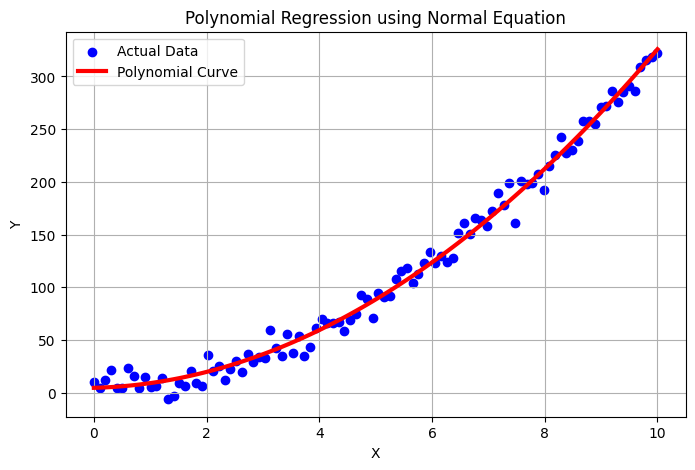

Theta:
[[4.48123648]
 [1.40490938]
 [3.07330233]]


In [8]:
plt.figure(figsize=(8,5))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', linewidth=3, label='Polynomial Curve')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Regression using Normal Equation")
plt.legend()
plt.grid(True)
plt.show()

print("Theta:")
print(theta)



---

GAUSSIAN REGG

---



In [24]:
np.random.seed(42)

X = np.linspace(0,10,100).reshape(-1,1)
y = np.sin(X) + np.random.randn(100,1)*0.15

In [25]:
# Number of Gaussian Basis Functions
M = 10

In [26]:

# Centers
centers = np.linspace(0,10,M)

sigma = 1.0

In [27]:
# Gaussian Basis Function
def gaussian(x,c,sigma):
    return np.exp(-(x-c)**2/(2*sigma**2))

# Design Matrix
Phi = np.ones((len(X),M+1))

In [28]:
for i,c in enumerate(centers):
    Phi[:,i+1] = gaussian(X[:,0],c,sigma)

# Normal Equation
theta = np.linalg.inv(Phi.T@Phi)@Phi.T@y

# Prediction
y_pred = Phi@theta

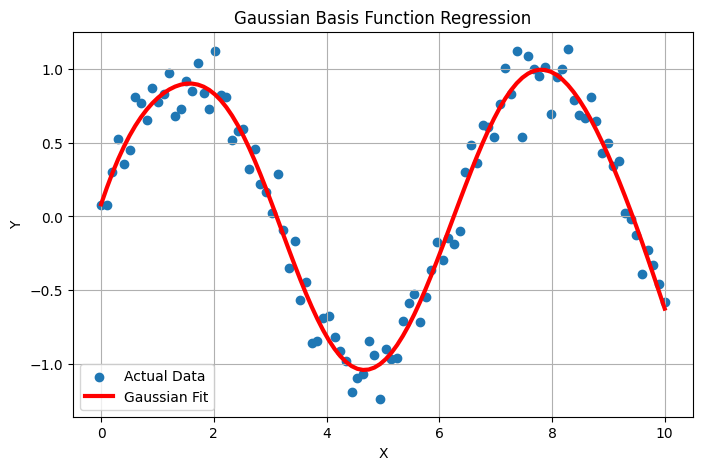

Theta:
[[-2.38834134]
 [ 1.6065812 ]
 [ 1.31334975]
 [ 1.7983857 ]
 [ 0.84148209]
 [ 0.33039921]
 [ 0.57976256]
 [ 1.35331543]
 [ 1.81751548]
 [ 1.31029266]
 [ 0.89877158]]


In [29]:
# Plot
plt.figure(figsize=(8,5))
plt.scatter(X,y,label='Actual Data')
plt.plot(X,y_pred,'r',linewidth=3,label='Gaussian Fit')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Gaussian Basis Function Regression")
plt.legend()
plt.grid(True)
plt.show()

print("Theta:")
print(theta)